## Homework

> Note: sometimes your answer doesn't match one of 
> the options exactly. That's fine. 
> Select the option that's closest to your solution.


In this homework, we will use the lead scoring dataset Bank Marketing dataset. Download it from [here](https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv).


In this dataset our desired target for classification task will be `converted` variable - has the client signed up to the platform or not. 

### Data preparation

* Check if the missing values are presented in the features.
* If there are missing values:
    * For caterogiral features, replace them with 'NA'
    * For numerical features, replace with with 0.0 


Split the data into 3 parts: train/validation/test with 60%/20%/20% distribution. Use `train_test_split` function for that with `random_state=1`








### Question 4: F1 score

Precision and recall are conflicting - when one grows, the other goes down. That's why they are often combined into the F1 score - a metrics that takes into account both

This is the formula for computing F1:

$$F_1 = 2 \cdot \cfrac{P \cdot R}{P + R}$$

Where $P$ is precision and $R$ is recall.

Let's compute F1 for all thresholds from 0.0 to 1.0 with increment 0.01

At which threshold F1 is maximal?

- 0.14
- 0.34
- 0.54
- 0.74


### Question 5: 5-Fold CV


Use the `KFold` class from Scikit-Learn to evaluate our model on 5 different folds:

```
KFold(n_splits=5, shuffle=True, random_state=1)
```

* Iterate over different folds of `df_full_train`
* Split the data into train and validation
* Train the model on train with these parameters: `LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)`
* Use AUC to evaluate the model on validation

How large is standard deviation of the scores across different folds?

- 0.0001
- 0.006
- 0.06
- 0.36


### Question 6: Hyperparameter Tuning

Now let's use 5-Fold cross-validation to find the best parameter `C`

* Iterate over the following `C` values: `[0.000001, 0.001, 1]`
* Initialize `KFold` with the same parameters as previously
* Use these parameters for the model: `LogisticRegression(solver='liblinear', C=C, max_iter=1000)`
* Compute the mean score as well as the std (round the mean and std to 3 decimal digits)

Which `C` leads to the best mean score?

- 0.000001
- 0.001
- 1

If you have ties, select the score with the lowest std. If you still have ties, select the smallest `C`.

## Submit the results

* Submit your results here: https://courses.datatalks.club/ml-zoomcamp-2025/homework/hw04
* If your answer doesn't match options exactly, select the closest one

In [43]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mutual_info_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv")

In [4]:
df.columns = df.columns.str.lower().str.replace(" ", "_")
categorical_columns = list(df.dtypes[df.dtypes == "object"].index)
for c in df.columns:
    if c in categorical_columns:
        df[c] = df[c].str.lower().str.replace(" ", "_")
        df[c] = df[c].fillna('NA')
    else:
        df[c] = df[c].fillna(0.0)

In [6]:
df_full_train, df_test = train_test_split(df, test_size= 0.4, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

y_train = df_train['converted']
y_val = df_val['converted']
y_test = df_test['converted']

del df_train['converted']
del df_val['converted']
del df_test['converted']

### Question 1: ROC AUC feature importance

ROC AUC could also be used to evaluate feature importance of numerical variables. 

Let's do that

* For each numerical variable, use it as score (aka prediction) and compute the AUC with the `y` variable as ground truth.
* Use the training dataset for that


If your AUC is < 0.5, invert this variable by putting "-" in front

(e.g. `-df_train['balance']`)

AUC can go below 0.5 if the variable is negatively correlated with the target variable. You can change the direction of the correlation by negating this variable - then negative correlation becomes positive.

Which numerical variable (among the following 4) has the highest AUC?

- `lead_score`
- [X]`number_of_courses_viewed`
- `interaction_count`
- `annual_income`

In [7]:
df_train.head(10)

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score
1096,events,finance,2,73688.0,self_employed,asia,2,0.07
787,NA,manufacturing,1,84548.0,employed,africa,6,0.57
1460,referral,NA,5,71016.0,self_employed,north_america,0,0.25
340,organic_search,education,3,69033.0,self_employed,north_america,1,0.43
783,organic_search,other,2,56446.0,self_employed,middle_east,2,0.09
128,paid_ads,education,1,67902.0,employed,africa,3,0.70
307,social_media,retail,4,50961.0,student,south_america,1,1.00
54,organic_search,retail,2,66775.0,unemployed,europe,2,0.32
1392,paid_ads,finance,1,65782.0,self_employed,australia,4,0.82
22,referral,other,3,72729.0,student,middle_east,3,0.60


In [9]:
numerical_columns = [ 'number_of_courses_viewed', 'annual_income', 'interaction_count', 'lead_score']


In [20]:
for n in numerical_columns:
    print(n, roc_auc_score(y_train, df_train[n]))

number_of_courses_viewed 0.7624201424407944
annual_income 0.5555914767134392
interaction_count 0.7337389743490765
lead_score 0.6146522939144197


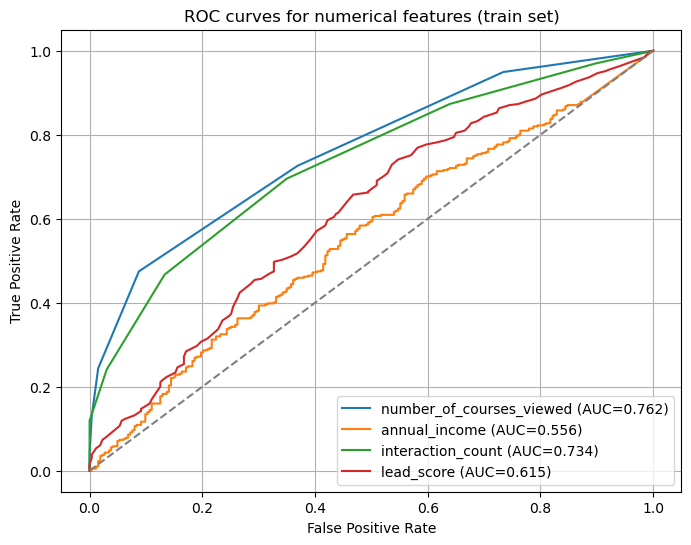

In [ ]:
plt.figure(figsize=(8, 6))
for n in numerical_columns:
    score = df_train[n] 
    auc = roc_auc_score(y_train, score)
    if auc < 0.5:
        score = -score
        auc = roc_auc_score(y_train, score)
    fpr, tpr, _ = roc_curve(y_train, score)
    plt.plot(fpr, tpr, label=f"{n} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="grey")
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC curves')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Question 2: Training the model

Apply one-hot-encoding using `DictVectorizer` and train the logistic regression with these parameters:

```python
LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
```

What's the AUC of this model on the validation dataset? (round to 3 digits)

- 0.32
- 0.52
- [X] 0.72
- 0.92

note: I get a score of 0.81, which is between two of the answers, but coser to 0.72, so I will mark than. If I scale the numerical values though, I get a score of 0.89...

In [71]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter = 1000)
model.fit(X_train, y_train)

In [ ]:
y_pred_val = model.predict_proba(X_val)[:, 1] 

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


ROC AUC (validation): 0.811617372768452  AUC from curve: 0.811617372768452


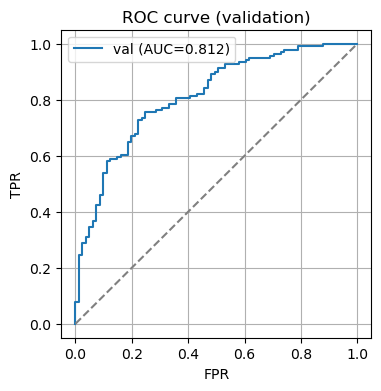

In [ ]:
fpr, tpr, _ = roc_curve(y_val, y_pred_val)
print('ROC AUC (validation):', roc_auc_score(y_val, y_pred_val), ' AUC from curve:', auc(fpr, tpr))
plt.figure(figsize=(4, 4))
plt.plot(fpr, tpr, label=f'val (AUC={roc_auc_score(y_val, y_pred_val):.3f})')
plt.plot([0, 1], [0, 1], linestyle="--", color="grey")
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC curve (validation)')
plt.legend()
plt.grid(True)
plt.show()

In [111]:
dict_train_categorical = df_train[categorical_columns].to_dict(orient='records')
dict_val_categorical = df_val[categorical_columns].to_dict(orient='records')

dv2 = DictVectorizer(sparse=False)
X_train_categorical = dv2.fit_transform(dict_train_categorical)
X_val_categorical = dv2.transform(dict_val_categorical)

scaler = StandardScaler()
X_train_num = df_train[numerical_columns].values
X_val_num = df_val[numerical_columns].values
X_train_num = scaler.fit_transform(X_train_num)
X_val_num = scaler.transform(X_val_num)

X_train_scaled = np.column_stack([X_train_num, X_train_categorical])
X_val_scaled = np.column_stack([X_val_num,X_val_categorical])

In [112]:
model2 = LogisticRegression(solver='liblinear', C=1.0, max_iter = 1000)
model2.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [113]:
y_preds_scaled = model2.predict_proba(X_val_scaled)[:, 1]

In [115]:
fpr,tpr,_ = roc_curve(y_val, y_preds_scaled)
print(roc_auc_score(y_val, y_preds_scaled))
# plt.figure(figsize=(4,4))
# plt.plot(fpr,tpr)

0.8895994315658584



### Question 3: Precision and Recall

Now let's compute precision and recall for our model.

* Evaluate the model on all thresholds from 0.0 to 1.0 with step 0.01
* For each threshold, compute precision and recall
* Plot them

At which threshold precision and recall curves intersect?

* 0.145
* 0.345
* 0.545
* 0.745
